In [3]:
import pandas as pd
df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

In [4]:
df.head(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [23]:
df.shape

(594194, 21)

In [5]:
df.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

# some data types are int they has to be encoded before training

In [8]:
df.duplicated().sum()#checks how many duplicate rows are in your dataset.

0

# df doesn't have any duplicate rows

In [6]:
df.isna().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# By first glance the data is clean

In [7]:

non_numeric = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

# Show the unique "invisible" values and how many there are
print(non_numeric['TotalCharges'].value_counts())

Series([], Name: TotalCharges, dtype: int64)


# This finds any row where TotalCharges is NOT a number

In [4]:
df['Churn'].value_counts()

No     460377
Yes    133817
Name: Churn, dtype: int64

In [24]:
df['Churn'].value_counts(normalize=True)

No     0.774792
Yes    0.225208
Name: Churn, dtype: float64

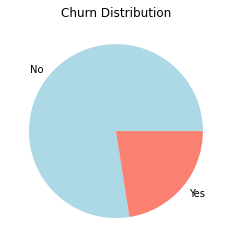

In [29]:
import matplotlib.pyplot as plt
df['Churn'].value_counts().plot.pie(
    colors=['lightblue', 'salmon']
)
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

# Dataset is imbalaced

In [5]:
corr_matrix = df.corr()
corr_matrix

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
id,1.000000,0.002035,0.019322,0.005729,0.014331
SeniorCitizen,0.002035,1.000000,-0.084291,0.229079,0.042786
tenure,0.019322,-0.084291,1.000000,0.124043,0.769703
MonthlyCharges,0.005729,0.229079,0.124043,1.000000,0.634237
TotalCharges,0.014331,0.042786,0.769703,0.634237,1.000000


# We observe that TotalCharges and MonthlyCharges are closely related, with a correlation coefficient of 0.63.This makes sense as the higher the monthly charges are, the more totalcharges will be. 

In [7]:
# Generate crosstab
res = pd.crosstab(df['Contract'], df['Churn'])

print(res)

Churn               No     Yes
Contract                      
Month-to-month  173210  125708
One year        102090    6243
Two year        185077    1866


# people who has contract month to month has more chance to churn

In [9]:
df.groupby("Dependents")["Churn"].value_counts()

Dependents  Churn
No          No       293636
            Yes      120726
Yes         No       166741
            Yes       13091
Name: Churn, dtype: int64

# Customers who do not have dependents are more likely to churn

In [27]:
df.groupby("Partner")["Churn"].value_counts

Partner  Churn
No       No       192240
         Yes       92400
Yes      No       268137
         Yes       41417
Name: Churn, dtype: int64

In [10]:
df.groupby("PaymentMethod")["Churn"].value_counts()

PaymentMethod              Churn
Bank transfer (automatic)  No       112004
                           Yes        9356
Credit card (automatic)    No       124435
                           Yes        9270
Electronic check           No       110044
                           Yes      105328
Mailed check               No       113894
                           Yes        9863
Name: Churn, dtype: int64

# customers who has payment method as Electronic check are more likely to churn when compared to other

In [11]:
df.groupby("PhoneService")["Churn"].value_counts()

PhoneService  Churn
No            No        30197
              Yes        6104
Yes           No       430180
              Yes      127713
Name: Churn, dtype: int64

# Customers who has Phoneservice a slightly high likely to churn than other

In [12]:
df.groupby("InternetService")["Churn"].value_counts()

InternetService  Churn
DSL              No       162418
                 Yes       18663
Fiber optic      No       159246
                 Yes      113140
No               No       138713
                 Yes        2014
Name: Churn, dtype: int64

# customers who has Internet service as Fiber Optic are more likely to churn .

In [13]:
df.groupby("OnlineSecurity")["Churn"].value_counts()

OnlineSecurity       Churn
No                   No       171909
                     Yes      117565
No internet service  No       138713
                     Yes        2014
Yes                  No       149755
                     Yes       14238
Name: Churn, dtype: int64

In [14]:
df.groupby("OnlineBackup")["Churn"].value_counts()

OnlineBackup         Churn
No                   No       152294
                     Yes       97789
No internet service  No       138713
                     Yes        2014
Yes                  No       169370
                     Yes       34014
Name: Churn, dtype: int64

In [15]:
df.groupby("DeviceProtection")["Churn"].value_counts()

DeviceProtection     Churn
No                   No       153218
                     Yes       94159
No internet service  No       138713
                     Yes        2014
Yes                  No       168446
                     Yes       37644
Name: Churn, dtype: int64

In [22]:
ad_ons= ((df['DeviceProtection'] == 'No') & (df["OnlineBackup"] == 'No') & (df["OnlineSecurity"] == 'No') & (df['Churn'] == 'Yes'))##grouping the whole expression
df[ad_ons]#only the rows where ad_ons is True

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
12,12,Female,1,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,72.45,69.45,Yes
19,19,Female,0,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.20,100.20,Yes
35,35,Male,1,Yes,No,9,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.10,816.80,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594176,594176,Female,0,No,No,5,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),70.35,302.35,Yes
594179,594179,Male,1,No,No,8,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.20,773.75,Yes
594182,594182,Male,0,No,No,9,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,84.90,819.55,Yes
594187,594187,Male,0,Yes,Yes,3,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Electronic check,80.45,244.45,Yes


# Out of 133817 ,67078 customer without any add ons are more likely to Churn

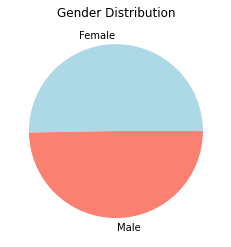

In [30]:
df['gender'].value_counts().plot.pie(
    colors=['lightblue', 'salmon']
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

column = ['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn']

In [12]:
for x in column:
    print(f"Unique values in {x}: {df[x].unique()}")

Unique values in id: [     0      1      2 ... 594191 594192 594193]
Unique values in gender: ['Male' 'Female']
Unique values in SeniorCitizen: [0 1]
Unique values in Partner: ['Yes' 'No']
Unique values in Dependents: ['Yes' 'No']
Unique values in tenure: [29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]
Unique values in PhoneService: ['Yes' 'No']
Unique values in MultipleLines: ['No' 'Yes' 'No phone service']
Unique values in InternetService: ['DSL' 'Fiber optic' 'No']
Unique values in OnlineSecurity: ['Yes' 'No' 'No internet service']
Unique values in OnlineBackup: ['No' 'Yes' 'No internet service']
Unique values in DeviceProtection: ['Yes' 'No' 'No internet service']
Unique values in TechSupport: ['Yes' 'No' 'No internet service']
Unique values in StreamingTV: ['No' 'Yes' 'No internet service']
Unique values in Stre

In [ ]:
#pip install category_encoders


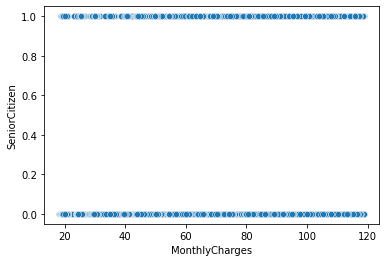

In [15]:
import seaborn as sns
sns.scatterplot(x = "MonthlyCharges", y ="SeniorCitizen", data = df )

C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


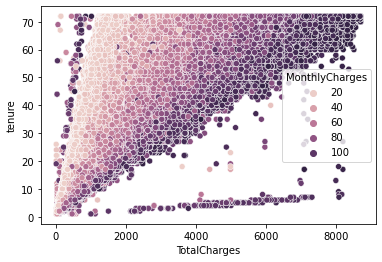

In [16]:
sns.scatterplot(x = "TotalCharges", y ="tenure",hue = "MonthlyCharges", data = df )

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001CBAC630160>,
      dtype=object)

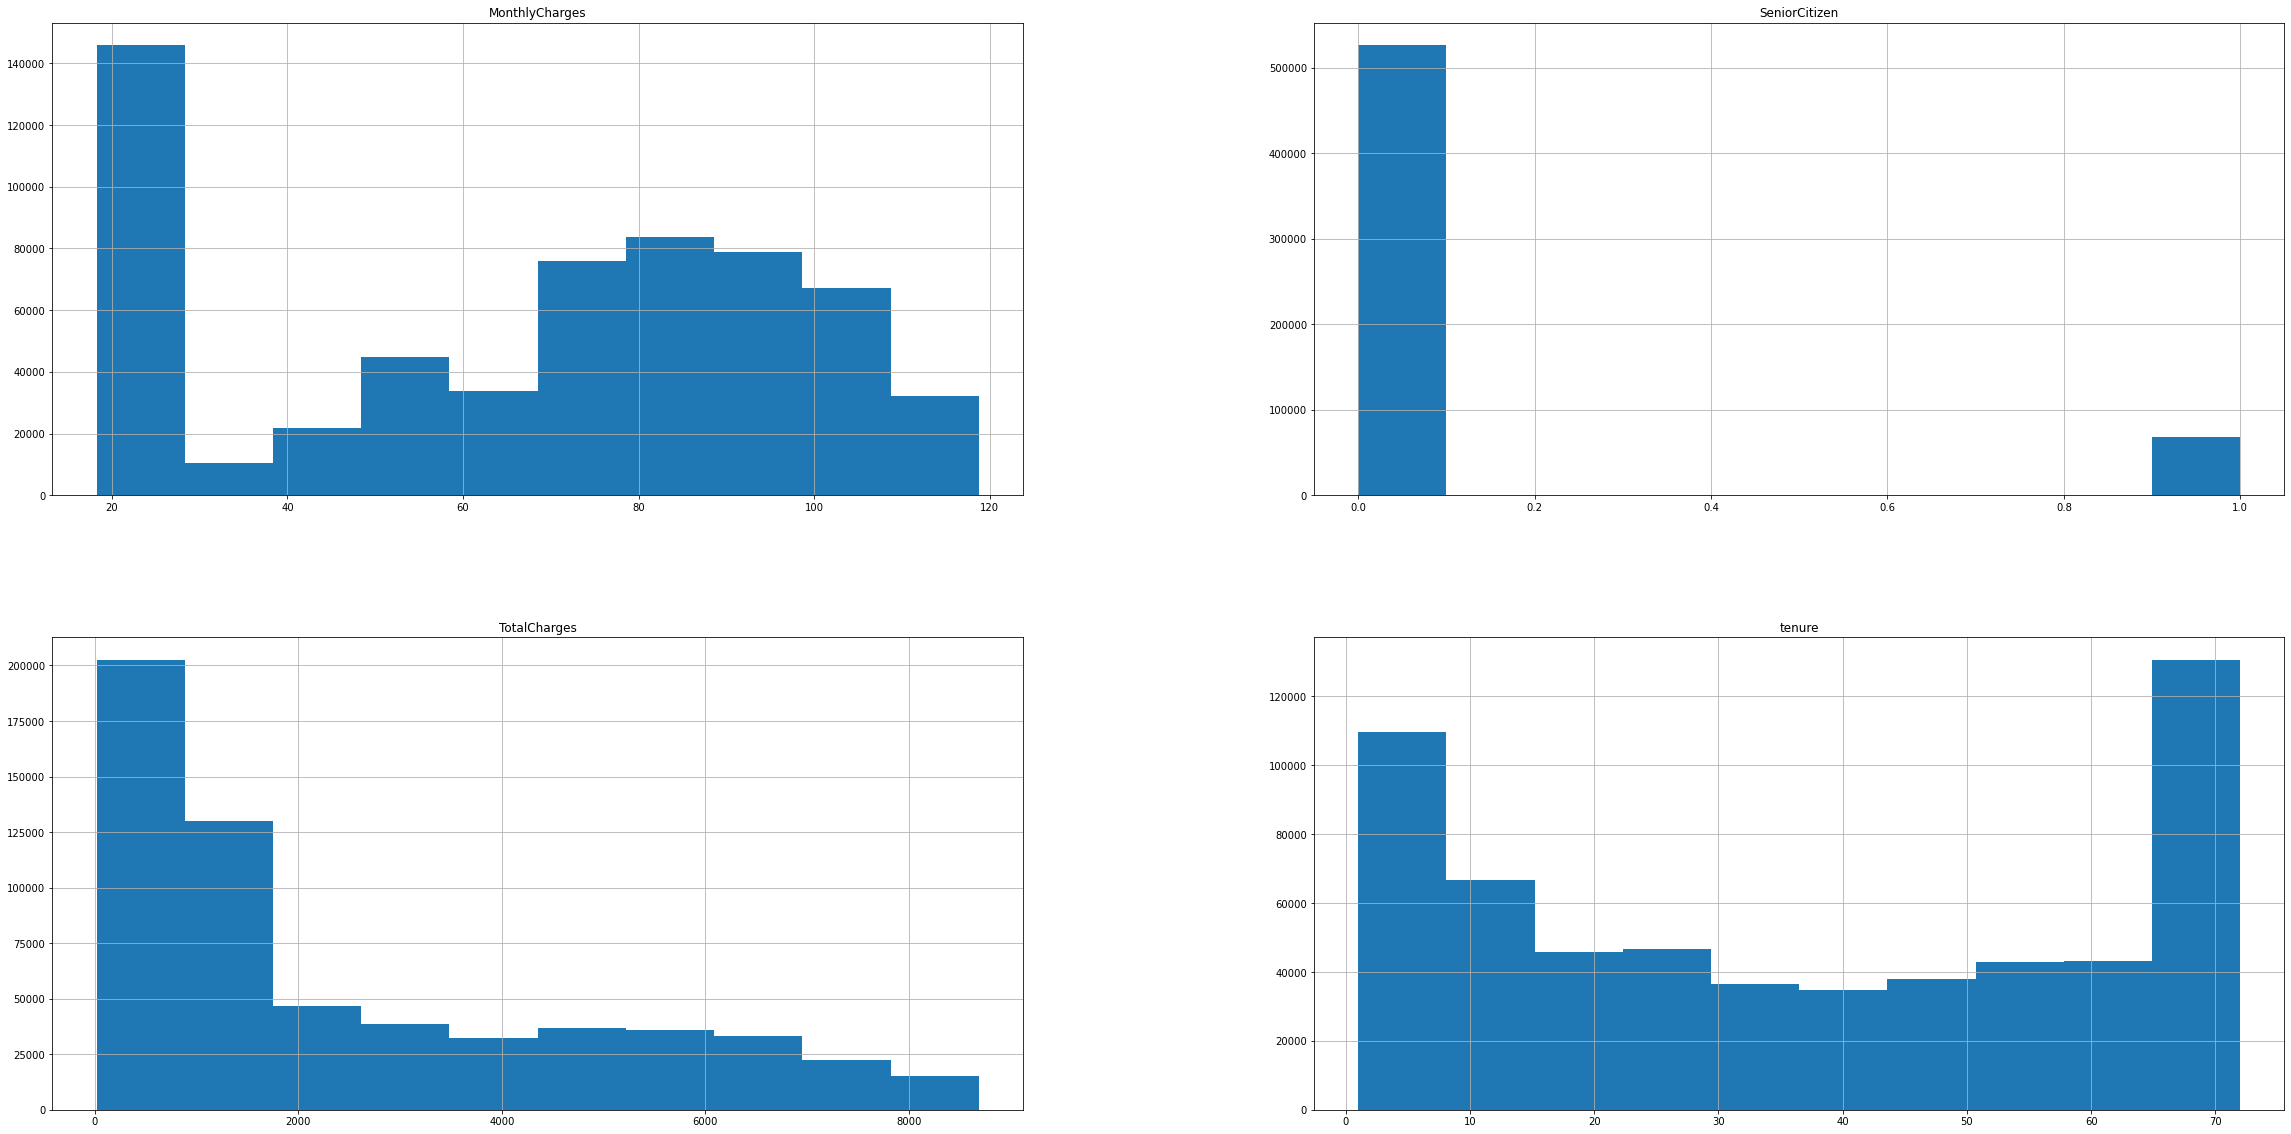

In [19]:
df.hist(bins = 10, figsize =(40,20))

# monthly chargesskewed to left and total charges to right. so log transform will be applied to totalcharges
#Senior citizen is binary 

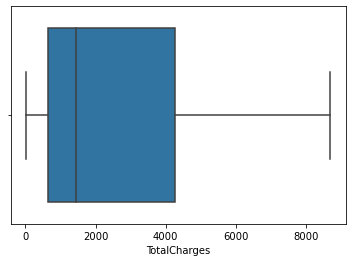

In [22]:
import seaborn as sns
sns.boxplot(x=df['TotalCharges'])

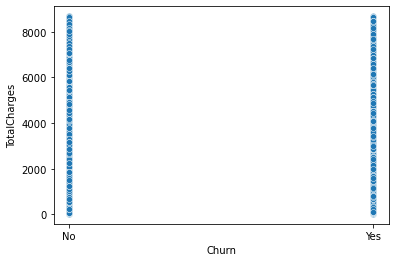

In [24]:
sns.scatterplot(x=df['Churn'],y=df['TotalCharges'])

In [26]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


# for tenure the mostly 25 to 75% are between 12 and 62, so min and max are potential outliers, but they are real world values.


# for  MonthlyCharges 25 to 75 % are between 29 to 90 , so min ans max are potential outliers,  but they are real world values.


# for Total Charges 25 to 75 % are between 18 to 8684 , so min and max are potential outliers, but they are real world values.


# Although TotalCharges contains low-value outliers, Since tree-based models like XGBoost are robust to outliers, these values are retained